# CommonRoad Monitor Scenario Evaluation


### Import Modules

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
%matplotlib notebook
#%matplotlib qt
import matplotlib.pyplot as plt
from IPython import display
from ipywidgets import widgets


from commonroad.common.file_reader import CommonRoadFileReader
from commonroad.scenario.obstacle import DynamicObstacle
from commonroad.visualization.draw_dispatch_cr import draw_object
from commonroad.visualization.plot_helper import *

from src.common.helper import *
from src.monitor.traffic_rule_dispatcher import TrafficRuleDispatcher
from src.common.vehicle import Vehicle
from src.common.road_network import RoadNetwork
from src.common.commonroad_evaluation import CommonRoadObstacleEvaluation
from src.output.visualization import Visualization

### Load scenario

In [2]:
scenario_path = "../scenarios/test/"
#scenario_path = "../../../commonroad/scenarios/datasets/highD/commonroad_scenarios/" 
scenarios = {1: "DEU_test_max_speed_limit",
             2: "DEU_test_min_speed_limit",
             3: "DEU_test_preserve_traffic_flow",
             4: "DEU_test_safe_distance",
             5: "DEU_test_standstill",
             6: "DEU_test_unnecessary_braking",
             7: "DEU_test_safe_distance_lane_change",
             8: "DEU_test_reversing_and_u_turn",
             9: "DEU_test_emergency_three_lanes_with_shoulder",
            10: "DEU_test_overtaking_exit_ramp",
            11: "DEU_test_overtaking_access_ramp",
            12: "DEU_test_overtaking_right_congestion",
            13: "DEU_test_overtaking_right_broad_lane_marking",
            14: "DEU_test_overtaking_right_normal",
            15: "DEU_test_consider_entering_vehicles_for_lane_change",
            16: "DEU_test_emergency_two_lanes_not_broad_enough",
            17: "DEU_test_consider_entering_vehicles_for_distance_1",
            18: "DEU_test_consider_entering_vehicles_for_distance_2",
            20: "ZAM-Ramp-1_1-T-1",
            19: "DEU_LocationBLower-1_1_T-1"}
selected_scenario = 20

In [3]:
scenario, planning_problem_set = \
            CommonRoadFileReader(scenario_path + scenarios.get(selected_scenario) + ".xml").open()
cr_eval = CommonRoadObstacleEvaluation("../src/")

### Auxiliary Functions

In [4]:
def get_max_time():
    max_time = 0
    for obs in scenario.dynamic_obstacles:
        if obs.prediction is None:
            continue
        if obs.prediction.trajectory.state_list[-1].time_step > max_time:
            max_time = obs.prediction.trajectory.state_list[-1].time_step
    return max_time

### Plot scenario

<IPython.core.display.Javascript object>


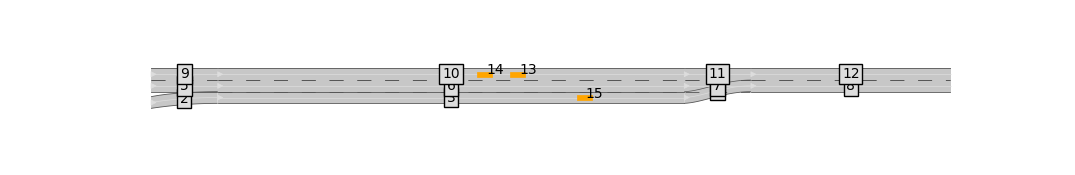

interactive(children=(IntSlider(value=0, description='t', max=50), Output()), _dom_classes=('widget-interact',…

In [7]:
vis = Visualization(ego_vehicle_ids=[1000, 1001], figsize=(10.75,1.75), ego_vehicle_color={1000:"#2d7bc2ff", 1001:"#2d7bc2ff"})
#vis.plot_scenario(scenario, time_begin=13, obstacle_label=False, lanelet_label=False)
def draw_state(t):
    print("current time step: ", t)
    vis.plot_scenario(scenario, time_begin=t, obstacle_label=True, lanelet_label=True)

# use the slider to have at look at every time step of the planned trajectory
w = widgets.interact(draw_state, t=widgets.IntSlider(min=0, max=get_max_time(), step=1, value=0))

### Rule evaluation

In [6]:
eval_result = cr_eval.evaluate_scenario(scenario)

scenario  ZAM-Ramp-1_1-T-1  could not be evaluated: Attribute Error


Traceback (most recent call last):
  File "/media/sebastian/TUM/06_code/research/commonroad_monitor/src/common/commonroad_evaluation.py", line 225, in evaluate_scenario
    result = self._execute_evaluation(scenario)
  File "/media/sebastian/TUM/06_code/research/commonroad_monitor/src/common/commonroad_evaluation.py", line 161, in _execute_evaluation
    self._road_network = RoadNetwork(scenario.lanelet_network, self._road_network_param)
  File "/media/sebastian/TUM/06_code/research/commonroad_monitor/src/common/road_network.py", line 159, in __init__
    self.lanes = self._create_lanes(road_network_param)
  File "/media/sebastian/TUM/06_code/research/commonroad_monitor/src/common/road_network.py", line 176, in _create_lanes
    if not lanelet.lanelet_type == pred.lanelet_type:
AttributeError: 'NoneType' object has no attribute 'lanelet_type'
